<div align="center">

# 📱 **Smartphone Usage & Digital Behavior EDA Project**


<img src= "https://i.postimg.cc/0QYFQ3GK/Designer-(1).png"
width="800">

</div>

# 📱 Project Overview

## Smartphone Usage and Digital Behavior Analysis

### 📌 Overview

This project focuses on performing **Exploratory Data Analysis (EDA)** on a large-scale dataset containing **1 million smartphone users and 12 features**. The objective is to understand smartphone usage patterns and analyze the relationship between screen time, social media usage, gaming, work/study activities, sleep, notifications, and app usage.

The project explores user behavior across different **age groups, genders, and academic/work impact levels**. Various data analysis techniques are used to identify patterns, trends, relationships, and unusual values in the dataset.

### 🎯 Objectives

* Understand the structure and characteristics of the dataset.
* Perform data quality checks.
* Analyze missing and duplicate values.
* Study the distribution of numerical variables.
* Detect outliers using **IQR and Z-score methods**.
* Analyze smartphone usage across different demographic groups.
* Explore the relationship between **screen time and sleep**.
* Examine social media, gaming, and work/study usage patterns.
* Perform correlation analysis between numerical variables.
* Generate meaningful insights using data visualization.

### 📊 Dataset

The dataset contains:

* **1,000,000 rows**
* **12 columns**

It includes information such as:

`Age, Gender, Daily Screen Time, Social Media Hours, Gaming Hours, Work/Study Hours, Sleep Hours, Notifications, App Opens, Weekend Screen Time, and Academic/Work Impact.`

### 🛠️ Tools and Technologies

* **Python**
* **Pandas**
* **NumPy**
* **Matplotlib**
* **Seaborn**
* **SciPy**
* **Jupyter Notebook**

### 📈 Expected Outcome

The project aims to discover meaningful patterns in smartphone usage and understand how different digital habits may relate to **sleep, productivity, and academic/work impact**. The analysis demonstrates practical skills in **data cleaning, statistical analysis, outlier detection, correlation analysis, and data visualization**.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


In [ ]:
df = pd.read_csv(r"/content/smartphone_usage_1_million_rows.csv")

In [ ]:
df

,User_ID,Age,Gender,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours,Academic_Work_Impact
0,1,22,Male,4.76,1.53,1.25,1.65,8.75,95,47,4.81,Low
1,2,55,Male,5.93,3.18,1.09,2.48,7.05,132,52,4.74,Low
2,3,49,Female,5.89,0.90,3.36,1.64,6.43,87,46,7.59,Medium
3,4,39,Female,5.39,0.94,0.41,4.56,6.06,81,24,7.17,Medium
4,5,38,Female,5.49,3.21,2.28,0.45,7.02,113,49,7.32,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999996,56,Male,6.68,3.11,3.57,0.78,8.58,147,38,8.15,Medium
999996,999997,40,Male,6.64,1.79,2.27,3.03,7.12,141,35,9.24,Medium
999997,999998,62,Female,6.60,3.28,1.57,1.96,7.53,115,49,5.58,Medium
999998,999999,20,Male,3.84,1.83,0.25,1.80,7.13,72,18,7.38,Low


### About the dataset

In [ ]:
print(f'Shape Of the Dataset: {df.shape}')

Shape Of the Dataset: (1000000, 12)


In [ ]:
print(f'Columns of the Dataset:{df.columns}')

Columns of the Dataset:Index(['User_ID', 'Age', 'Gender', 'Daily_Screen_Time_Hours',
       'Social_Media_Hours', 'Gaming_Hours', 'Work_Study_Hours', 'Sleep_Hours',
       'Notifications_Per_Day', 'App_Opens_Per_Day',
       'Weekend_Screen_Time_Hours', 'Academic_Work_Impact'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   User_ID                    1000000 non-null  int64  
 1   Age                        1000000 non-null  int64  
 2   Gender                     1000000 non-null  object 
 3   Daily_Screen_Time_Hours    1000000 non-null  float64
 4   Social_Media_Hours         1000000 non-null  float64
 5   Gaming_Hours               1000000 non-null  float64
 6   Work_Study_Hours           1000000 non-null  float64
 7   Sleep_Hours                1000000 non-null  float64
 8   Notifications_Per_Day      1000000 non-null  int64  
 9   App_Opens_Per_Day          1000000 non-null  int64  
 10  Weekend_Screen_Time_Hours  1000000 non-null  float64
 11  Academic_Work_Impact       1000000 non-null  object 
dtypes: float64(6), int64(4), object(2)
memory usage: 91.6+ MB


In [ ]:
df.describe()

,User_ID,Age,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,41.485183,6.203156,2.480795,1.598684,2.440214,7.133903,111.282411,42.957427,7.005419
std,288675.278933,13.848346,2.093304,1.263580,1.042071,1.769107,0.838767,44.917382,17.615518,2.508331
min,1.000000,18.000000,0.500000,0.080000,0.000000,0.000000,3.500000,5.000000,1.000000,0.500000
25%,250000.750000,29.000000,4.780000,1.500000,0.790000,0.970000,6.570000,81.000000,31.000000,5.300000
50%,500000.500000,41.000000,6.200000,2.290000,1.410000,2.240000,7.130000,111.000000,43.000000,7.000000
75%,750000.250000,53.000000,7.620000,3.290000,2.200000,3.590000,7.700000,142.000000,55.000000,8.700000
max,1000000.000000,65.000000,15.000000,9.670000,9.320000,12.260000,10.000000,331.000000,124.000000,16.000000


In [ ]:
# First 5 rows
df.head()

,User_ID,Age,Gender,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours,Academic_Work_Impact
0,1,22,Male,4.76,1.53,1.25,1.65,8.75,95,47,4.81,Low
1,2,55,Male,5.93,3.18,1.09,2.48,7.05,132,52,4.74,Low
2,3,49,Female,5.89,0.90,3.36,1.64,6.43,87,46,7.59,Medium
3,4,39,Female,5.39,0.94,0.41,4.56,6.06,81,24,7.17,Medium
4,5,38,Female,5.49,3.21,2.28,0.45,7.02,113,49,7.32,Low


In [ ]:
# Last 5 rows
df.tail()

,User_ID,Age,Gender,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours,Academic_Work_Impact
999995,999996,56,Male,6.68,3.11,3.57,0.78,8.58,147,38,8.15,Medium
999996,999997,40,Male,6.64,1.79,2.27,3.03,7.12,141,35,9.24,Medium
999997,999998,62,Female,6.60,3.28,1.57,1.96,7.53,115,49,5.58,Medium
999998,999999,20,Male,3.84,1.83,0.25,1.80,7.13,72,18,7.38,Low
999999,1000000,24,Male,6.50,4.10,0.96,1.68,7.48,146,48,6.94,Medium


In [ ]:
df.sample(5)

,User_ID,Age,Gender,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours,Academic_Work_Impact
818339,818340,24,Female,4.59,2.47,2.12,0.68,8.22,103,19,7.30,Low
272073,272074,27,Male,5.23,1.80,0.70,2.94,7.61,32,36,5.60,Low
70369,70370,62,Female,7.16,2.49,0.75,3.40,7.41,99,66,6.01,Medium
322779,322780,25,Female,6.08,3.68,0.86,2.55,6.55,122,30,8.85,Medium
669390,669391,23,Female,7.14,3.29,1.95,2.64,5.87,67,64,7.80,Medium


In [ ]:
df.dtypes

,0
User_ID,int64
Age,int64
Gender,object
Daily_Screen_Time_Hours,float64
Social_Media_Hours,float64
Gaming_Hours,float64
Work_Study_Hours,float64
Sleep_Hours,float64
Notifications_Per_Day,int64
App_Opens_Per_Day,int64


### DATA CLEANING

In [ ]:
df.isna()

,User_ID,Age,Gender,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours,Academic_Work_Impact
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,False,False,False,False,False,False,False,False,False,False,False,False
999996,False,False,False,False,False,False,False,False,False,False,False,False
999997,False,False,False,False,False,False,False,False,False,False,False,False
999998,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
User_ID,0
Age,0
Gender,0
Daily_Screen_Time_Hours,0
Social_Media_Hours,0
Gaming_Hours,0
Work_Study_Hours,0
Sleep_Hours,0
Notifications_Per_Day,0
App_Opens_Per_Day,0


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
User_ID,0.0
Age,0.0
Gender,0.0
Daily_Screen_Time_Hours,0.0
Social_Media_Hours,0.0
Gaming_Hours,0.0
Work_Study_Hours,0.0
Sleep_Hours,0.0
Notifications_Per_Day,0.0
App_Opens_Per_Day,0.0


### Check Duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["User_ID"].duplicated().sum()

np.int64(0)

### Check Unique Values

In [ ]:
df.nunique()

,0
User_ID,1000000
Age,48
Gender,3
Daily_Screen_Time_Hours,1410
Social_Media_Hours,850
Gaming_Hours,791
Work_Study_Hours,1077
Sleep_Hours,637
Notifications_Per_Day,307
App_Opens_Per_Day,121


### Check Categorical Values

In [ ]:
df["Gender"].value_counts()

,count
Gender,
Female,490195
Male,489762
Other,20043


In [ ]:
df["Academic_Work_Impact"].value_counts()

,count
Academic_Work_Impact,
Medium,548711
Low,352143
High,99146


### Data Cleaning

In [ ]:
### Descriptive Analysis

df.describe()

,User_ID,Age,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,41.485183,6.203156,2.480795,1.598684,2.440214,7.133903,111.282411,42.957427,7.005419
std,288675.278933,13.848346,2.093304,1.263580,1.042071,1.769107,0.838767,44.917382,17.615518,2.508331
min,1.000000,18.000000,0.500000,0.080000,0.000000,0.000000,3.500000,5.000000,1.000000,0.500000
25%,250000.750000,29.000000,4.780000,1.500000,0.790000,0.970000,6.570000,81.000000,31.000000,5.300000
50%,500000.500000,41.000000,6.200000,2.290000,1.410000,2.240000,7.130000,111.000000,43.000000,7.000000
75%,750000.250000,53.000000,7.620000,3.290000,2.200000,3.590000,7.700000,142.000000,55.000000,8.700000
max,1000000.000000,65.000000,15.000000,9.670000,9.320000,12.260000,10.000000,331.000000,124.000000,16.000000


In [ ]:
### Mean , Median , Mode
df.select_dtypes(include=np.number).mean()

,0
User_ID,500000.500000
Age,41.485183
Daily_Screen_Time_Hours,6.203156
Social_Media_Hours,2.480795
Gaming_Hours,1.598684
Work_Study_Hours,2.440214
Sleep_Hours,7.133903
Notifications_Per_Day,111.282411
App_Opens_Per_Day,42.957427
Weekend_Screen_Time_Hours,7.005419


In [ ]:
df.select_dtypes(include=np.number).median()

,0
User_ID,500000.50
Age,41.00
Daily_Screen_Time_Hours,6.20
Social_Media_Hours,2.29
Gaming_Hours,1.41
Work_Study_Hours,2.24
Sleep_Hours,7.13
Notifications_Per_Day,111.00
App_Opens_Per_Day,43.00
Weekend_Screen_Time_Hours,7.00


In [ ]:
df.select_dtypes(include=np.number).mode()

,User_ID,Age,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours
0,1,23.0,0.5,1.41,0.74,0.0,7.2,5.0,43.0,0.5
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
999995,999996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999996,999997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999997,999998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999998,999999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.select_dtypes(include=np.number).std()

,0
User_ID,288675.278933
Age,13.848346
Daily_Screen_Time_Hours,2.093304
Social_Media_Hours,1.263580
Gaming_Hours,1.042071
Work_Study_Hours,1.769107
Sleep_Hours,0.838767
Notifications_Per_Day,44.917382
App_Opens_Per_Day,17.615518
Weekend_Screen_Time_Hours,2.508331


### Distribution Analysis
Analyze how data is distributed.

Important columns:

* Age
* Daily Screen Time
* Social Media Hours
* Gaming Hours
* Sleep Hours
* Notifications

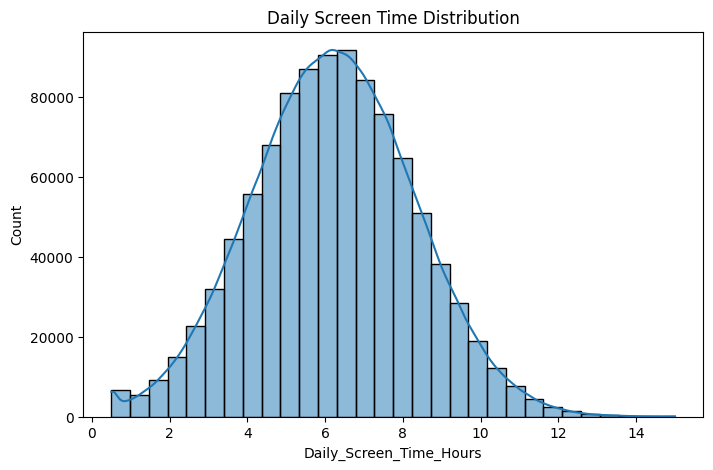

In [ ]:
plt.figure(figsize =(8,5))
sns.histplot(df["Daily_Screen_Time_Hours"],bins=30,kde=True)
plt.title("Daily Screen Time Distribution")
plt.show()

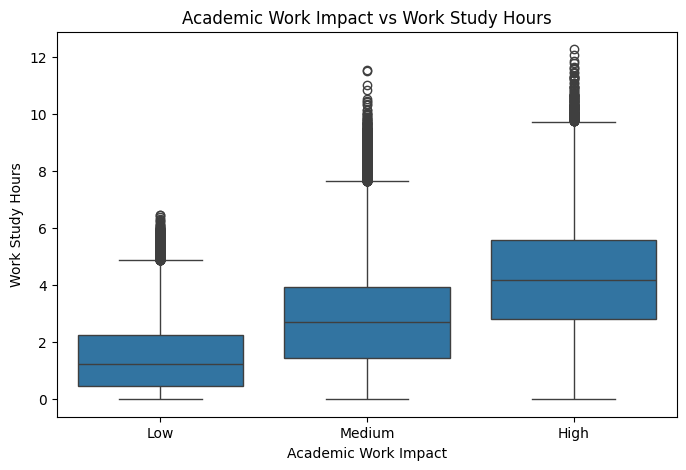

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Academic_Work_Impact"],
    y=df["Work_Study_Hours"]
)

plt.title("Academic Work Impact vs Work Study Hours")
plt.xlabel("Academic Work Impact")
plt.ylabel("Work Study Hours")

plt.show()

In [ ]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Daily_Screen_Time_Hours',
       'Social_Media_Hours', 'Gaming_Hours', 'Work_Study_Hours', 'Sleep_Hours',
       'Notifications_Per_Day', 'App_Opens_Per_Day',
       'Weekend_Screen_Time_Hours', 'Academic_Work_Impact'],
      dtype='object')

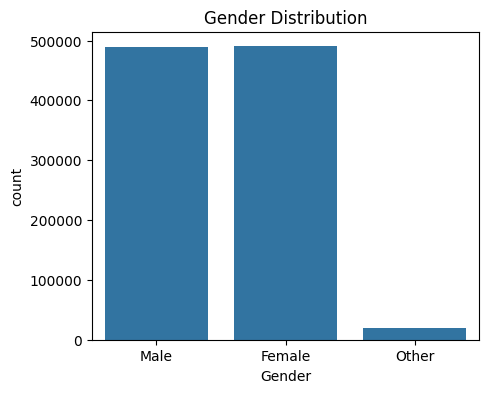

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(
    data=df,
    x="Gender"
)
plt.title("Gender Distribution")
plt.show()

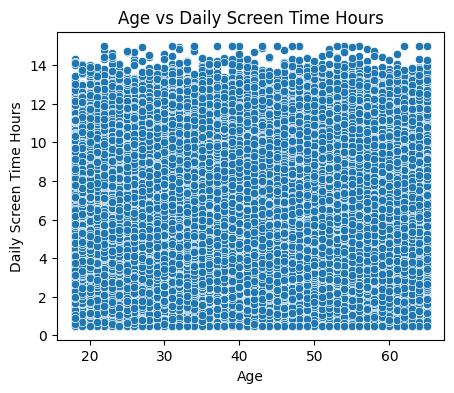

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=df,
    x="Age",
    y="Daily_Screen_Time_Hours"
)
plt.title("Age vs Daily Screen Time Hours")
x=plt.xlabel("Age")
y=plt.ylabel("Daily Screen Time Hours")
plt.show()

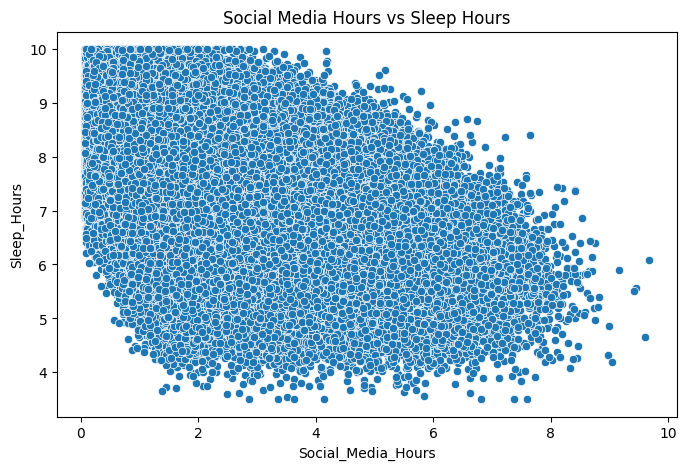

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Social_Media_Hours",
    y="Sleep_Hours"
)

plt.title("Social Media Hours vs Sleep Hours")
plt.show()

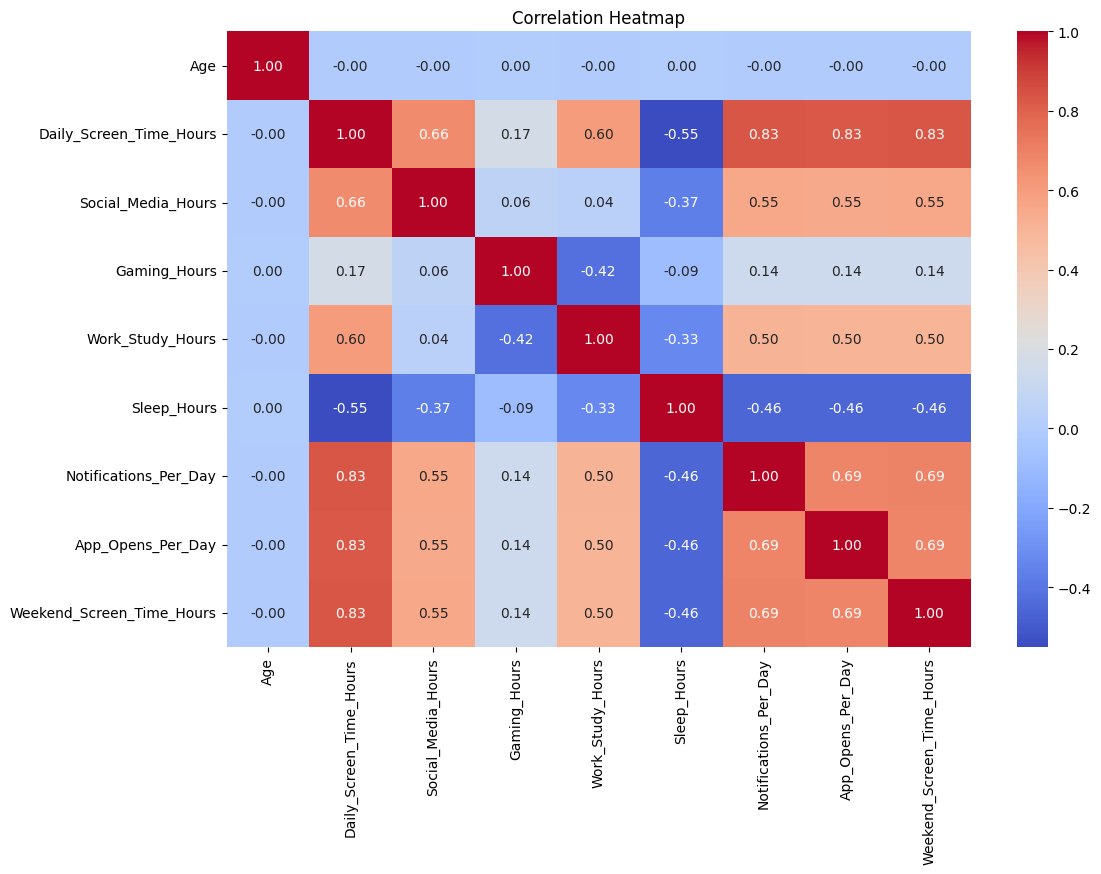

In [ ]:
numeric_df = df.select_dtypes(include="number")

numeric_df = numeric_df.drop(columns=["User_ID"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
df.select_dtypes(include="number").skew()

,0
User_ID,-2.511790e-15
Age,1.243761e-03
Daily_Screen_Time_Hours,2.492779e-02
Social_Media_Hours,6.829186e-01
Gaming_Hours,9.677975e-01
Work_Study_Hours,6.503830e-01
Sleep_Hours,-3.827057e-03
Notifications_Per_Day,6.600906e-02
App_Opens_Per_Day,6.061131e-02
Weekend_Screen_Time_Hours,3.908731e-02


In [ ]:
df.select_dtypes(include="number").kurt()

,0
User_ID,-1.200000
Age,-1.200270
Daily_Screen_Time_Hours,-0.072823
Social_Media_Hours,0.134140
Gaming_Hours,1.013989
Work_Study_Hours,-0.006747
Sleep_Hours,-0.015696
Notifications_Per_Day,-0.156982
App_Opens_Per_Day,-0.158657
Weekend_Screen_Time_Hours,-0.116835


In [ ]:
Q1 = df["Daily_Screen_Time_Hours"].quantile(0.25)

Q3 = df["Daily_Screen_Time_Hours"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

In [ ]:
outliers = df[
    (df["Daily_Screen_Time_Hours"] < lower_bound) |
    (df["Daily_Screen_Time_Hours"] > upper_bound)
]

outliers.shape

(6867, 12)

### Outlier Detection using Z-score


In [ ]:
z_scores = zscore(df["Daily_Screen_Time_Hours"])

outliers_z = df[
    np.abs(z_scores) > 3
]

outliers_z.shape

(1376, 12)

### Univariate Analysis

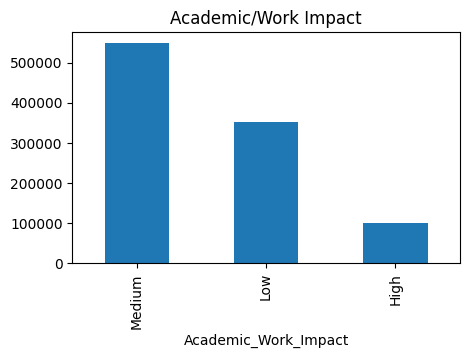

In [ ]:
plt.figure(figsize=(5,3))

df["Academic_Work_Impact"].value_counts().plot(
    kind="bar"
)

plt.title("Academic/Work Impact")

plt.show()


### Bivariate Analysis

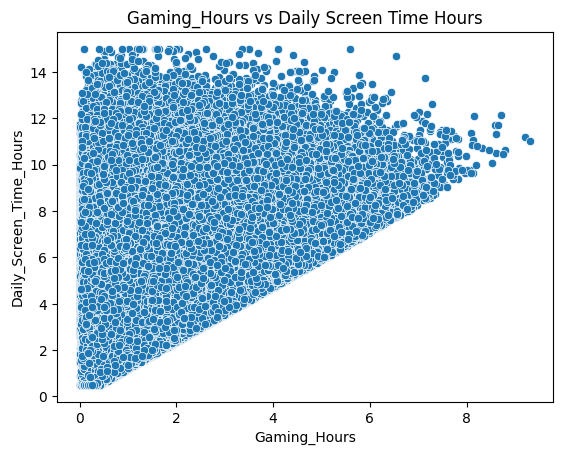

In [ ]:
sns.scatterplot(
    data=df,
    x="Gaming_Hours",
    y="Daily_Screen_Time_Hours"
)
plt.title("Gaming_Hours vs Daily Screen Time Hours")
plt.show()

### GROUP ANALYSIS

In [ ]:
## Gender-wise group analysis

df.groupby("Age")["Daily_Screen_Time_Hours"].mean()

,Daily_Screen_Time_Hours
Age,
18,6.198995
19,6.194668
20,6.193021
21,6.176828
22,6.211458
23,6.211002
24,6.230249
25,6.216401
26,6.191432


In [ ]:
### Gender_wise_sleep

df.groupby("Gender")["Sleep_Hours"].mean()

,Sleep_Hours
Gender,
Female,7.133613
Male,7.134116
Other,7.135774


In [ ]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Daily_Screen_Time_Hours',
       'Social_Media_Hours', 'Gaming_Hours', 'Work_Study_Hours', 'Sleep_Hours',
       'Notifications_Per_Day', 'App_Opens_Per_Day',
       'Weekend_Screen_Time_Hours', 'Academic_Work_Impact'],
      dtype='object')

In [ ]:
## Impact-wise screen time

df.groupby("User_ID")["Weekend_Screen_Time_Hours"].mean()

,Weekend_Screen_Time_Hours
User_ID,
1,4.81
2,4.74
3,7.59
4,7.17
5,7.32
...,...
999996,8.15
999997,9.24
999998,5.58


In [ ]:
df["Age_Group"] = pd.cut(df["Age"],
        bins=[17,25,35,45,55,65],
        labels=[
          "18-25",
          "26-35",
          "36-45",
          "46-55",
          "56-65"
        ]
)

In [ ]:
df

,User_ID,Age,Gender,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours,Academic_Work_Impact,Age_Group
0,1,22,Male,4.76,1.53,1.25,1.65,8.75,95,47,4.81,Low,18-25
1,2,55,Male,5.93,3.18,1.09,2.48,7.05,132,52,4.74,Low,46-55
2,3,49,Female,5.89,0.90,3.36,1.64,6.43,87,46,7.59,Medium,46-55
3,4,39,Female,5.39,0.94,0.41,4.56,6.06,81,24,7.17,Medium,36-45
4,5,38,Female,5.49,3.21,2.28,0.45,7.02,113,49,7.32,Low,36-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999996,56,Male,6.68,3.11,3.57,0.78,8.58,147,38,8.15,Medium,56-65
999996,999997,40,Male,6.64,1.79,2.27,3.03,7.12,141,35,9.24,Medium,36-45
999997,999998,62,Female,6.60,3.28,1.57,1.96,7.53,115,49,5.58,Medium,56-65
999998,999999,20,Male,3.84,1.83,0.25,1.80,7.13,72,18,7.38,Low,18-25


In [ ]:
### Analyze Age Group

df.groupby("Age_Group")["Daily_Screen_Time_Hours"].mean()

/tmp/ipykernel_4567/27265905.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Daily_Screen_Time_Hours"].mean()


,Daily_Screen_Time_Hours
Age_Group,
18-25,6.204054
26-35,6.209267
36-45,6.201627
46-55,6.201082
56-65,6.199924


/tmp/ipykernel_4567/3762438410.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")[


Text(0, 0.5, 'Daily_Screen_Time_Hours')

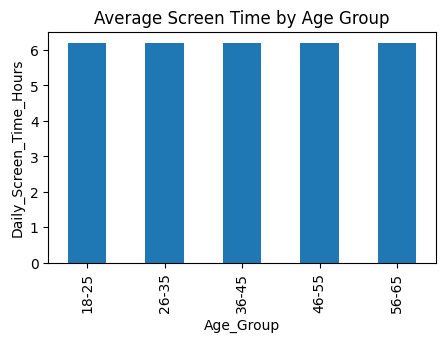

In [ ]:
plt.figure(figsize=(5,3))
df.groupby("Age_Group")[
    "Daily_Screen_Time_Hours"
].mean().plot(kind='bar')

plt.title("Average Screen Time by Age Group")

plt.xlabel("Age_Group")

plt.ylabel("Daily_Screen_Time_Hours")


In [ ]:
df[
    [
        "Daily_Screen_Time_Hours",
        "Weekend_Screen_Time_Hours"
    ]
].mean()

,0
Daily_Screen_Time_Hours,6.203156
Weekend_Screen_Time_Hours,7.005419


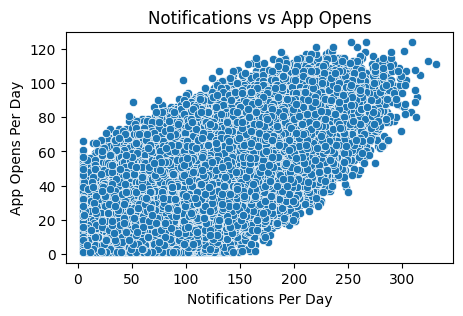

In [ ]:

plt.figure(figsize=(5, 3))

sns.scatterplot(
    data=df,
    x="Notifications_Per_Day",
    y="App_Opens_Per_Day"
)

plt.title("Notifications vs App Opens")
plt.xlabel("Notifications Per Day")
plt.ylabel("App Opens Per Day")

plt.show()

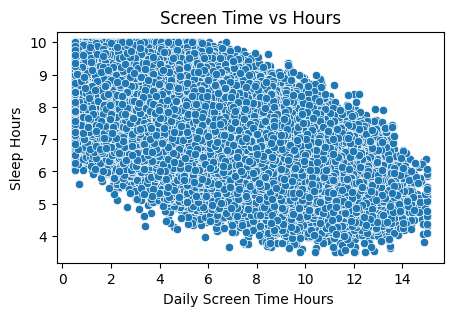

In [ ]:
plt.figure(figsize=(5, 3))

sns.scatterplot(
    data=df,
    x="Daily_Screen_Time_Hours",
    y="Sleep_Hours"
)

plt.title("Screen Time vs Hours")
plt.xlabel("Daily Screen Time Hours ")
plt.ylabel("Sleep Hours")

plt.show()

In [ ]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Daily_Screen_Time_Hours',
       'Social_Media_Hours', 'Gaming_Hours', 'Work_Study_Hours', 'Sleep_Hours',
       'Notifications_Per_Day', 'App_Opens_Per_Day',
       'Weekend_Screen_Time_Hours', 'Academic_Work_Impact', 'Age_Group'],
      dtype='object')

In [ ]:
### Academic/Work Impact Analysis

impact_analysis = df.groupby(
    "Academic_Work_Impact"
)[
    [
        "Daily_Screen_Time_Hours",
        "Sleep_Hours",
        "Social_Media_Hours"
    ]
].mean()

impact_analysis

,Daily_Screen_Time_Hours,Sleep_Hours,Social_Media_Hours
Academic_Work_Impact,,,
High,9.389078,5.902432,3.760977
Low,4.245242,7.834382,1.696543
Medium,6.884014,6.906874,2.752784


In [125]:
### Compare Social Media and Gaming Hours
df[
    [
        "Social_Media_Hours",
        "Gaming_Hours"
   ]
].mean()

,0
Social_Media_Hours,2.480795
Gaming_Hours,1.598684


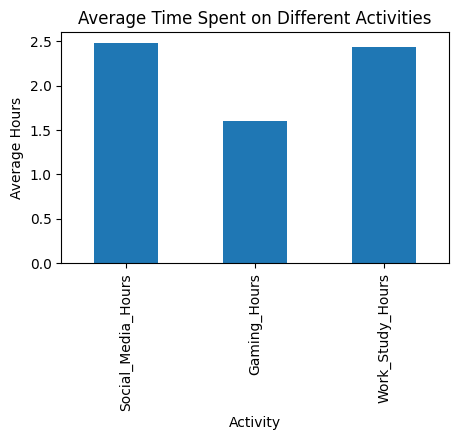

In [127]:
usage_comparison = df[
    [
        "Social_Media_Hours",
        "Gaming_Hours",
        "Work_Study_Hours"
    ]
].mean()

usage_comparison.plot(
    kind="bar",
    figsize=(5, 3)
)

plt.title("Average Time Spent on Different Activities")
plt.xlabel("Activity")
plt.ylabel("Average Hours")

plt.show()

In [129]:
### Gender-wise Smartphone usuage

gender_usage = df.groupby("Gender")[
    [
        "Daily_Screen_Time_Hours",
        "Social_Media_Hours",
        "Gaming_Hours",
        "Sleep_Hours"
    ]
].mean()

gender_usage

,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Sleep_Hours
Gender,,,,
Female,6.202058,2.479508,1.598654,7.133613
Male,6.205120,2.482511,1.598713,7.134116
Other,6.182034,2.470322,1.598669,7.135774


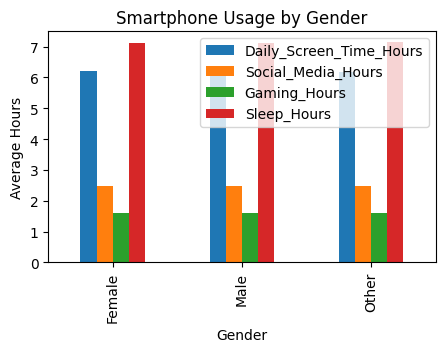

In [134]:
gender_usage.plot(
    kind="bar",
    figsize=(5,3)
)
plt.title("Smartphone Usage by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Hours")

plt.show()


In [135]:
### Find top smartphone users

top_users = df.nlargest(
    10,
    "Daily_Screen_Time_Hours"
)
top_users

,User_ID,Age,Gender,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours,Academic_Work_Impact,Age_Group
44259,44260,56,Female,15.0,8.98,2.05,4.29,4.31,324,113,16.00,High,56-65
71828,71829,43,Female,15.0,3.73,1.65,10.06,5.20,248,109,16.00,High,36-45
186158,186159,48,Female,15.0,6.29,1.22,8.44,5.04,258,121,16.00,High,46-55
216661,216662,37,Male,15.0,4.74,3.50,7.45,4.58,255,96,14.37,High,36-45
223216,223217,54,Female,15.0,3.58,1.31,10.93,5.50,302,86,13.56,High,46-55
363124,363125,22,Male,15.0,2.54,1.02,11.60,6.03,210,85,16.00,High,18-25
379559,379560,39,Female,15.0,4.11,1.55,9.62,5.86,286,91,16.00,High,36-45
398225,398226,56,Female,15.0,9.60,4.10,1.52,4.66,273,116,14.60,High,56-65
429455,429456,34,Male,15.0,3.20,0.10,11.46,5.92,246,115,16.00,High,26-35
465875,465876,31,Male,15.0,6.36,1.57,7.71,4.62,233,104,16.00,High,26-35


In [136]:
### Find users with lowest sleep

low_sleep_hours = df.nsmallest(
    10,
    "Sleep_Hours"
)
low_sleep_hours

,User_ID,Age,Gender,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours,Academic_Work_Impact,Age_Group
368699,368700,29,Male,10.41,2.86,0.47,7.10,3.50,215,81,12.07,High,26-35
415669,415670,37,Male,11.22,6.81,1.20,3.89,3.50,180,76,10.34,High,36-45
735142,735143,58,Female,11.46,3.36,2.43,6.49,3.50,235,70,12.30,High,56-65
735269,735270,43,Male,9.78,4.15,1.40,4.12,3.50,172,60,9.29,High,36-45
806046,806047,45,Male,12.01,3.64,2.29,6.30,3.50,224,64,13.74,High,36-45
902004,902005,21,Female,12.45,7.59,0.44,4.74,3.50,224,67,14.76,High,18-25
99052,99053,39,Female,12.06,7.38,1.05,4.23,3.51,211,84,12.17,High,36-45
291277,291278,30,Male,12.83,3.52,1.03,7.82,3.54,264,107,15.38,High,26-35
968293,968294,43,Female,11.62,5.84,3.24,2.87,3.56,216,67,11.49,High,36-45
107322,107323,49,Male,9.88,2.49,2.31,5.76,3.60,176,72,11.74,High,46-55


In [137]:
df["Screen_Time_Category"] = pd.cut(
    df["Daily_Screen_Time_Hours"],
    bins=[0,3,6,9,24],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very_High"
    ]
)

In [138]:
df["Screen_Time_Category"].value_counts()

,count
Screen_Time_Category,
High,446922
Moderate,398272
Very_High,90721
Low,64085


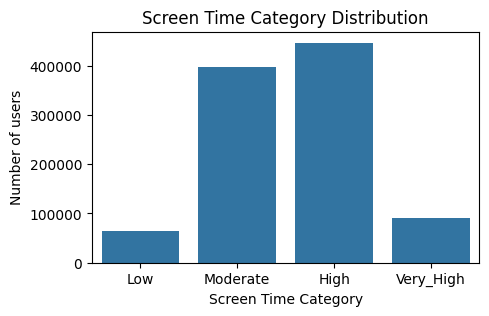

In [140]:
plt.figure(figsize=(5,3))
sns.countplot(
    data=df,
    x="Screen_Time_Category"

)
plt.title("Screen Time Category Distribution")
plt.xlabel("Screen Time Category")
plt.ylabel("Number of users")

plt.show()

In [141]:
summary = df.groupby(
    "Academic_Work_Impact"
).agg(
    Average_Screen_Time=(
        "Daily_Screen_Time_Hours",
        "mean"
    ),

    Average_Sleep=(
        "Sleep_Hours",
        "mean"
    ),

    Average_Social_Media=(
        "Social_Media_Hours",
        "mean"
    ),

    Average_Gaming=(
        "Gaming_Hours",
        "mean"
    )
)

summary

,Average_Screen_Time,Average_Sleep,Average_Social_Media,Average_Gaming
Academic_Work_Impact,,,,
High,9.389078,5.902432,3.760977,1.758400
Low,4.245242,7.834382,1.696543,1.430372
Medium,6.884014,6.906874,2.752784,1.677841


In [142]:
correlation = df.select_dtypes(
    include="number"
).corr()

correlation

,User_ID,Age,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Work_Study_Hours,Sleep_Hours,Notifications_Per_Day,App_Opens_Per_Day,Weekend_Screen_Time_Hours
User_ID,1.000000,-0.001331,-0.000487,0.000064,0.000294,-0.000854,0.000100,-0.000323,-0.000277,0.000189
Age,-0.001331,1.000000,-0.001085,-0.001663,0.000933,-0.000298,0.001022,-0.001352,-0.001612,-0.000221
Daily_Screen_Time_Hours,-0.000487,-0.001085,1.000000,0.663747,0.167402,0.603592,-0.551781,0.833464,0.825564,0.831407
Social_Media_Hours,0.000064,-0.001663,0.663747,1.000000,0.055172,0.036613,-0.366394,0.553166,0.547856,0.552009
Gaming_Hours,0.000294,0.000933,0.167402,0.055172,1.000000,-0.423429,-0.093028,0.139019,0.136472,0.138327
Work_Study_Hours,-0.000854,-0.000298,0.603592,0.036613,-0.423429,1.000000,-0.332256,0.503339,0.499477,0.501944
Sleep_Hours,0.000100,0.001022,-0.551781,-0.366394,-0.093028,-0.332256,1.000000,-0.460057,-0.455183,-0.458137
Notifications_Per_Day,-0.000323,-0.001352,0.833464,0.553166,0.139019,0.503339,-0.460057,1.000000,0.688674,0.693004
App_Opens_Per_Day,-0.000277,-0.001612,0.825564,0.547856,0.136472,0.499477,-0.455183,0.688674,1.000000,0.686149
Weekend_Screen_Time_Hours,0.000189,-0.000221,0.831407,0.552009,0.138327,0.501944,-0.458137,0.693004,0.686149,1.000000


In [143]:
correlation[
    "Daily_Screen_Time_Hours"
].sort_values(
    ascending=False
)

,Daily_Screen_Time_Hours
Daily_Screen_Time_Hours,1.000000
Notifications_Per_Day,0.833464
Weekend_Screen_Time_Hours,0.831407
App_Opens_Per_Day,0.825564
Social_Media_Hours,0.663747
Work_Study_Hours,0.603592
Gaming_Hours,0.167402
User_ID,-0.000487
Age,-0.001085
Sleep_Hours,-0.551781


### Final Insights

1. **Age Distribution:** Users are distributed across different age groups, allowing analysis of how social media behavior varies by age.

2. **Screen Time:** Daily screen time varies considerably among users, indicating different levels of digital device usage.

3. **Social Media Usage:** Social media contributes significantly to overall daily screen time.

4. **App Usage:** Users who open apps more frequently generally show higher digital engagement.

5. **Notifications:** Higher notification counts may be associated with increased app usage and screen time.

6. **Correlation Analysis:** The heatmap helps identify relationships between numerical variables such as screen time, social media hours, gaming hours, notifications, and app opens.

7. **Outliers:** Outlier detection using **IQR and Z-score methods** identified unusual observations that may represent extremely high or low user behavior.

8. **Data Distribution:** Skewness and kurtosis analysis helped understand whether numerical variables follow a normal distribution and whether extreme values are present.

9. **User Behavior Patterns:** Different users demonstrate different patterns of screen time, social media usage, gaming, work/study time, and sleep.

10. **Overall Conclusion:** The EDA successfully revealed important patterns, distributions, relationships, and unusual observations in the **1-million-row dataset**, demonstrating how exploratory data analysis can transform raw data into meaningful insights.

### Project Conclusion

**This project analyzed a large-scale dataset of 1 million user records to understand digital behavior patterns. Through data cleaning, univariate analysis, bivariate analysis, correlation analysis, distribution analysis, and outlier detection, meaningful insights were discovered about screen time, social media usage, app engagement, notifications, and other user behavior patterns.**

